<a href="https://colab.research.google.com/github/Malki9/3601763_BD2/blob/main/ML_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Business Understanding

Predicting whether a localised infrastructure failure is likely
(1) or unlikely (0) during a short monitoring window, based on environmental stress,
infrastructure composition, and operational conditions.

### Data Understanding

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv(r"/content/urbandata.csv")
df.shape

(456, 12)

In [ ]:
# Split the data to train and tes
from sklearn.model_selection import train_test_split
train, test = train_test_split(df, test_size=0.2, random_state=42)

In [ ]:
train.head()

,inspector_id,material_flexibility,structural_mass_ratio,recent_precipitation,infrastructure_age,surface_debris,vibration_exposure,asset_density,inspection_season,inspection_window,moisture_stress,failure
17,4,34.173746,13.018982,4.632811,70.597674,9.507074,4.988900,2.9100,summer,afternoon,0.08,1
66,7,34.208478,11.840893,3.422467,61.518576,9.538648,5.027916,2.7428,autumn,afternoon,0.02,0
305,4,36.044405,12.778856,4.722908,85.154762,10.349132,5.133635,2.9488,summer,morning,0.05,1
411,11,31.582666,11.801400,2.807081,57.403381,8.867654,4.945473,2.6048,winter,morning,0.01,0
31,4,28.405858,11.681774,1.836554,63.334801,8.302755,4.955494,2.4624,autumn,night,NaN,0


In [ ]:
train.shape

(364, 12)

In [ ]:
train.dtypes

,0
inspector_id,int64
material_flexibility,float64
structural_mass_ratio,float64
recent_precipitation,float64
infrastructure_age,float64
surface_debris,float64
vibration_exposure,float64
asset_density,float64
inspection_season,object
inspection_window,object


In [ ]:

train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 364 entries, 17 to 102
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   inspector_id           364 non-null    int64  
 1   material_flexibility   364 non-null    float64
 2   structural_mass_ratio  364 non-null    float64
 3   recent_precipitation   362 non-null    float64
 4   infrastructure_age     361 non-null    float64
 5   surface_debris         364 non-null    float64
 6   vibration_exposure     363 non-null    float64
 7   asset_density          364 non-null    float64
 8   inspection_season      364 non-null    object 
 9   inspection_window      364 non-null    object 
 10  moisture_stress        362 non-null    float64
 11  failure                364 non-null    int64  
dtypes: float64(8), int64(2), object(2)
memory usage: 37.0+ KB


In [ ]:
train.isnull().sum()

,0
inspector_id,0
material_flexibility,0
structural_mass_ratio,0
recent_precipitation,2
infrastructure_age,3
surface_debris,0
vibration_exposure,1
asset_density,0
inspection_season,0
inspection_window,0


In [ ]:
# Count the values in inspection_season
value_counts = df['inspection_season'].value_counts()

# Print the result
print(value_counts)

inspection_season
summer    133
autumn    122
winter    115
spring     85
sumer       1
Name: count, dtype: int64


In [ ]:
# Count the values in inspection_window
value_counts = df['inspection_window'].value_counts()

# Print the result
print(value_counts)

inspection_window
night        172
morning      148
afternoon    135
morni7ng       1
Name: count, dtype: int64


array([[<Axes: title={'center': 'inspector_id'}>,
        <Axes: title={'center': 'material_flexibility'}>,
        <Axes: title={'center': 'structural_mass_ratio'}>],
       [<Axes: title={'center': 'recent_precipitation'}>,
        <Axes: title={'center': 'infrastructure_age'}>,
        <Axes: title={'center': 'surface_debris'}>],
       [<Axes: title={'center': 'vibration_exposure'}>,
        <Axes: title={'center': 'asset_density'}>,
        <Axes: title={'center': 'moisture_stress'}>],
       [<Axes: title={'center': 'failure'}>, <Axes: >, <Axes: >]],
      dtype=object)

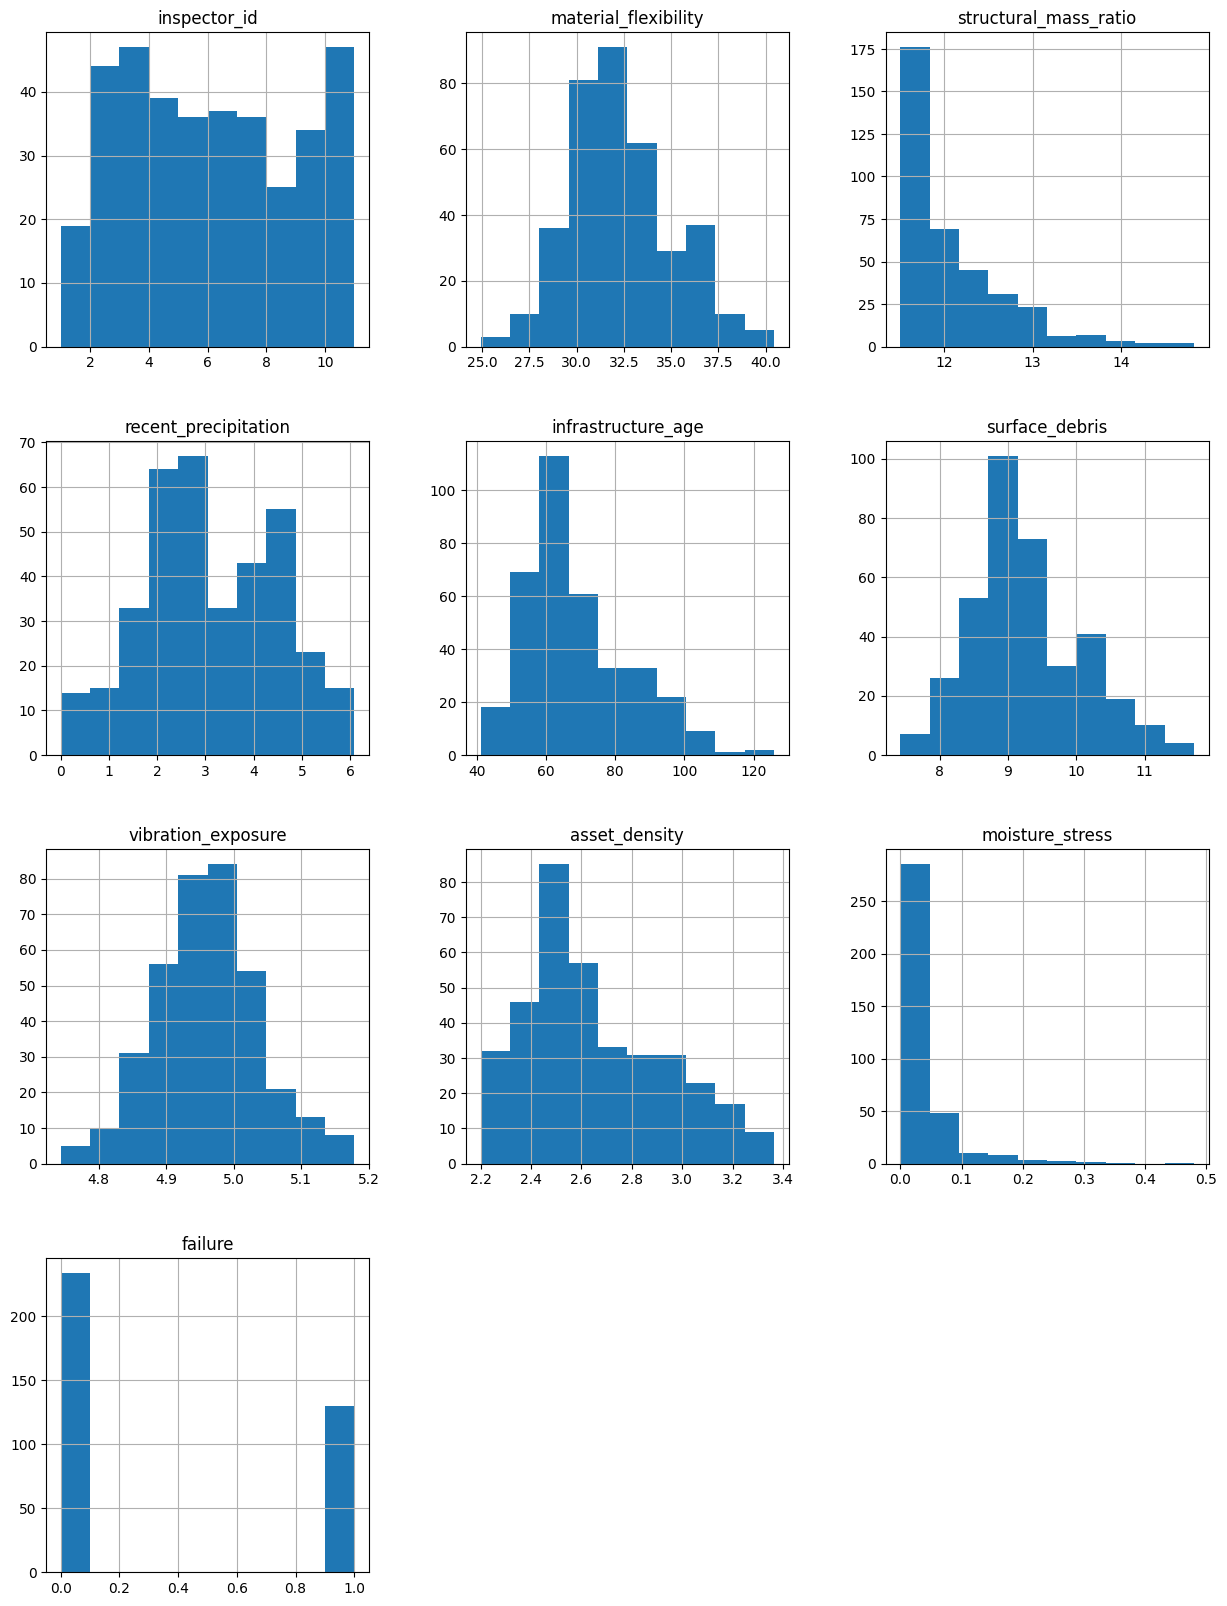

In [ ]:
train.hist(figsize = (15,20))

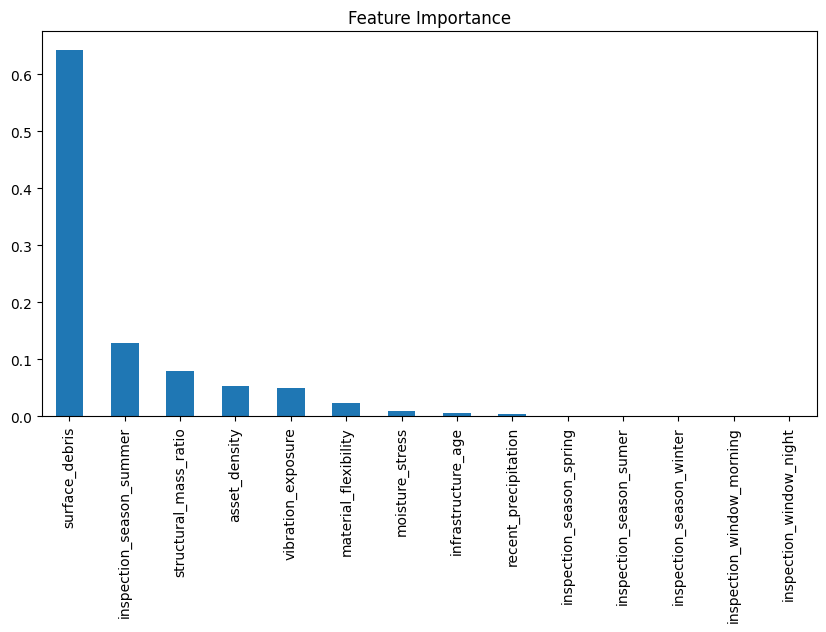

In [ ]:
from sklearn.tree import DecisionTreeClassifier

X = train.drop(['failure', 'inspector_id'], axis=1)
y = train['failure']

# Convert categorical to dummy
X = pd.get_dummies(X, drop_first=True)

model = DecisionTreeClassifier()
model.fit(X, y)

importances = model.feature_importances_

feature_importance = pd.Series(importances, index=X.columns)
feature_importance.sort_values(ascending=False).plot(kind='bar', figsize=(10,5))
plt.title("Feature Importance")
plt.show()

In [ ]:
# Selected features
features = ["surface_debris", "inspection_season", "vibration_exposure", "asset_density","structural_mass_ratio", "material_flexibility","recent_precipitation","moisture_stress"]
train = train[features]

# Data Preparation


In [ ]:
# checking the null values in the selected features
train.isnull().sum()

,0
surface_debris,0
inspection_season,0
vibration_exposure,1
asset_density,0
structural_mass_ratio,0
material_flexibility,0
recent_precipitation,2
moisture_stress,2


In [ ]:
# Data cleaning in the categorical varaible
train['inspection_season'].value_counts()

,count
inspection_season,
autumn,100
summer,99
winter,96
spring,68
sumer,1


In [ ]:
train['inspection_season'] = train['inspection_season'].replace({
    'sumer': 'summer'
})

In [ ]:
# Mean imputation
train['vibration_exposure'].fillna(train['vibration_exposure'].mean(), inplace=True)
train['recent_precipitation'].fillna(train['recent_precipitation'].mean(), inplace=True)

# Median imputation (skewed variable)
train['moisture_stress'].fillna(train['moisture_stress'].median(), inplace=True)

/tmp/ipykernel_10631/3947729241.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train['vibration_exposure'].fillna(train['vibration_exposure'].mean(), inplace=True)
/tmp/ipykernel_10631/3947729241.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[c

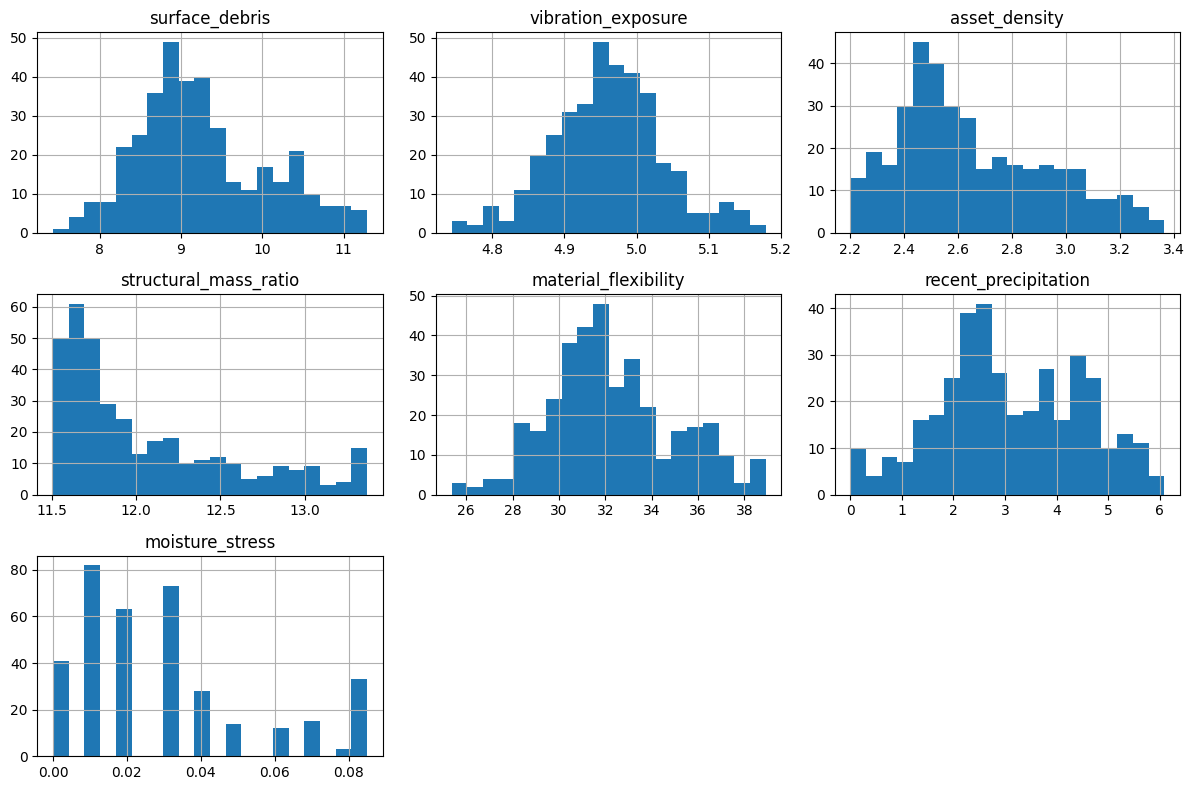

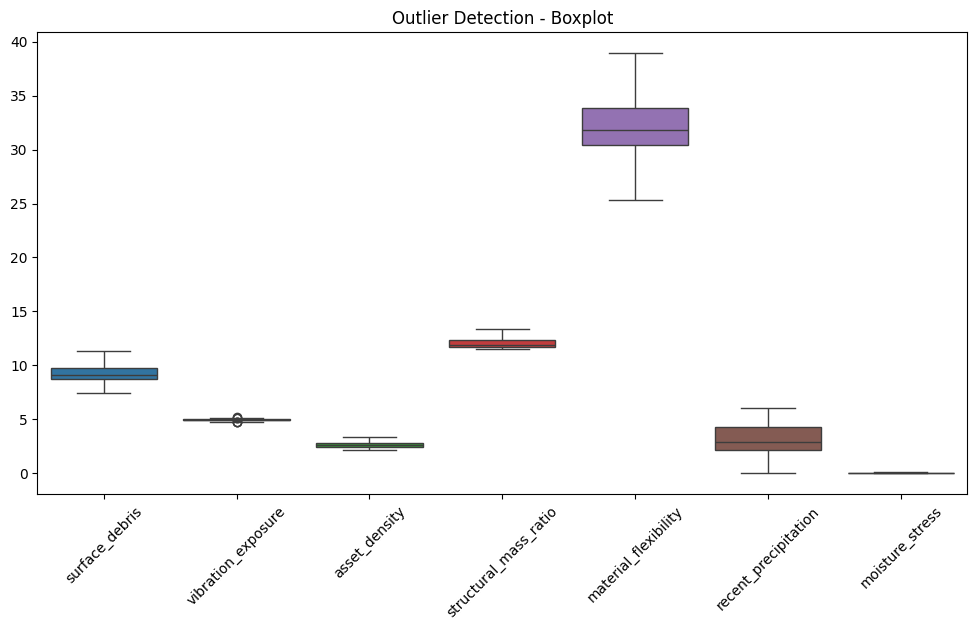

{'surface_debris': 0, 'vibration_exposure': 6, 'asset_density': 0, 'structural_mass_ratio': 0, 'material_flexibility': 0, 'recent_precipitation': 0, 'moisture_stress': 0}


In [ ]:
numeric_cols = [
    "surface_debris",
    "vibration_exposure",
    "asset_density",
    "structural_mass_ratio",
    "material_flexibility",
    "recent_precipitation",
    "moisture_stress"
]

import matplotlib.pyplot as plt

train[numeric_cols].hist(figsize=(12,8), bins=20)
plt.tight_layout()
plt.show()

import seaborn as sns

plt.figure(figsize=(12,6))
sns.boxplot(data=train[numeric_cols])
plt.xticks(rotation=45)
plt.title("Outlier Detection - Boxplot")
plt.show()

outlier_summary = {}

for col in numeric_cols:
    Q1 = train[col].quantile(0.25)
    Q3 = train[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = train[(train[col] < lower) | (train[col] > upper)]

    outlier_summary[col] = len(outliers)

print(outlier_summary)



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Your selected features
num_cols = [
    "surface_debris",
    "vibration_exposure",
    "asset_density",
    "structural_mass_ratio",
    "material_flexibility",
    "recent_precipitation",
    "moisture_stress"
]

# Function to detect outliers using IQR
def detect_outliers_iqr(df, cols):
    outlier_summary = {}

    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        outliers = df[(df[col] < lower) | (df[col] > upper)]

        outlier_summary[col] = len(outliers)

        print(f"{col}: {len(outliers)} outliers")

    return outlier_summary

# Run on TRAIN data
detect_outliers_iqr(train, num_cols)

surface_debris: 0 outliers
vibration_exposure: 6 outliers
asset_density: 0 outliers
structural_mass_ratio: 0 outliers
material_flexibility: 0 outliers
recent_precipitation: 0 outliers
moisture_stress: 0 outliers


{'surface_debris': 0,
 'vibration_exposure': 6,
 'asset_density': 0,
 'structural_mass_ratio': 0,
 'material_flexibility': 0,
 'recent_precipitation': 0,
 'moisture_stress': 0}

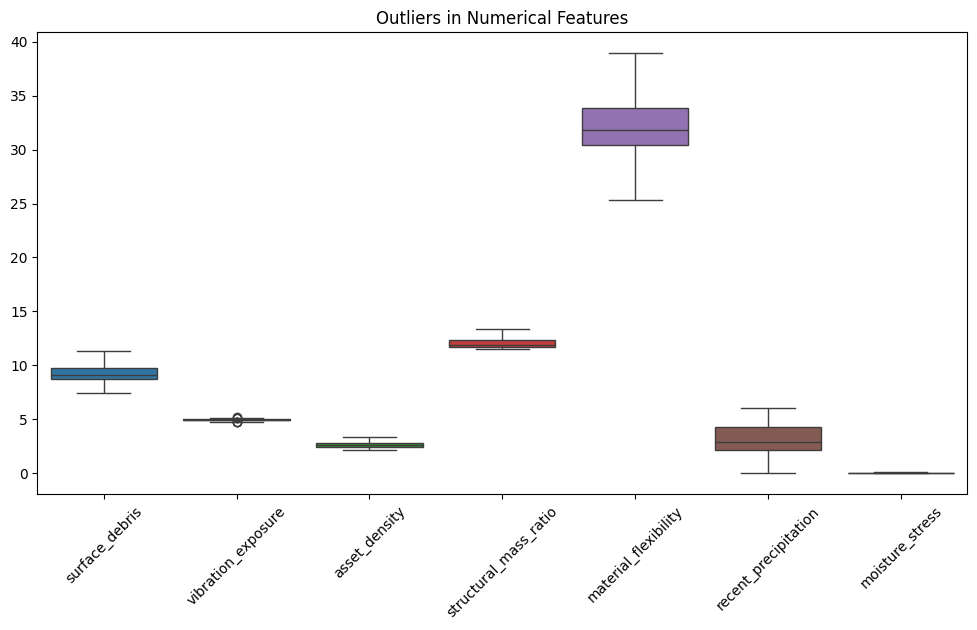

In [ ]:
plt.figure(figsize=(12,6))
sns.boxplot(data=train[num_cols])
plt.xticks(rotation=45)
plt.title("Outliers in Numerical Features")
plt.show()

In [ ]:
# Numerical columns WITH outliers (from your boxplot)
outlier_cols = [
    "surface_debris",
    "structural_mass_ratio",
    "material_flexibility",
    "recent_precipitation",
    "moisture_stress",
    "vibration_exposure"
]

# Function for IQR capping
def cap_outliers(df, cols):
    df = df.copy()

    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        print(f"{col}: Lower={lower:.2f}, Upper={upper:.2f}")

        df[col] = np.where(df[col] < lower, lower,
                           np.where(df[col] > upper, upper, df[col]))

    return df

# Apply ONLY on train data
train = cap_outliers(train, outlier_cols)

surface_debris: Lower=7.19, Upper=11.29
structural_mass_ratio: Lower=10.64, Upper=13.37
material_flexibility: Lower=25.37, Upper=38.92
recent_precipitation: Lower=-1.06, Upper=7.48
moisture_stress: Lower=-0.03, Upper=0.08
vibration_exposure: Lower=4.77, Upper=5.15


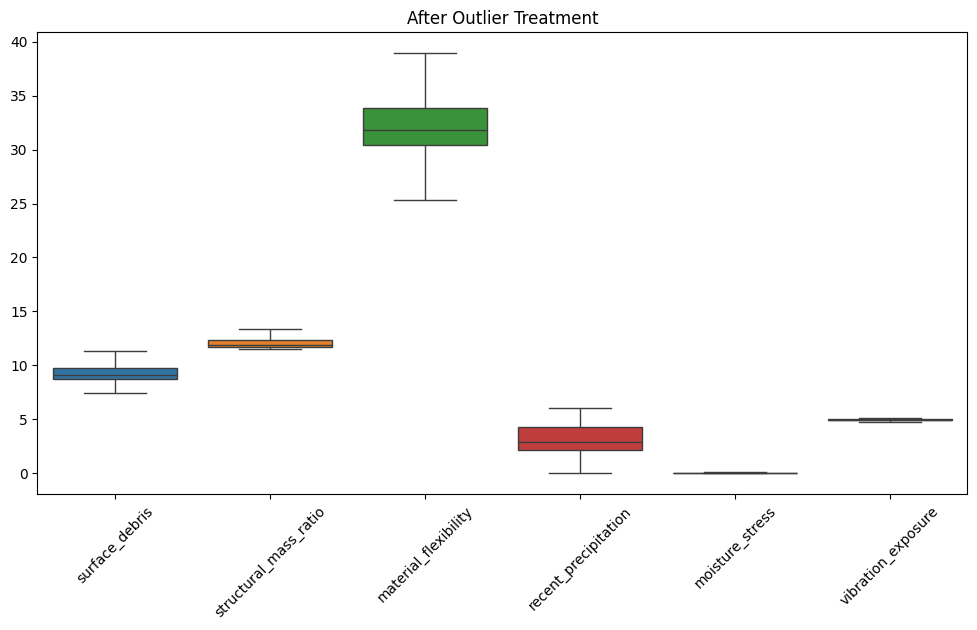

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
sns.boxplot(data=train[outlier_cols])
plt.title("After Outlier Treatment")
plt.xticks(rotation=45)
plt.show()

# Modelling and hyperparameter Tuning

In [ ]:
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

categorical_features = ["inspection_season"]
numeric_features = [
    "surface_debris",
    "vibration_exposure",
    "asset_density",
    "structural_mass_ratio",
    "material_flexibility",
    "recent_precipitation",
    "moisture_stress"
]

# For Logistic Regression and Neural Network: scaling needed
numeric_transformer_scaled = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# For Decision Tree: scaling not needed
numeric_transformer_unscaled = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore"))
])

preprocessor_scaled = ColumnTransformer(transformers=[
    ("num", numeric_transformer_scaled,numeric_features ),
    ("cat", categorical_transformer, categorical_features)
])

preprocessor_unscaled = ColumnTransformer(transformers=[
    ("num", numeric_transformer_unscaled, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])


In [ ]:
target = "failure"

X_train = train.copy()
y_train = y.copy() # Use the 'y' variable created earlier as 'failure' column is no longer in 'train'

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Logistic Regression Grid Search
lr_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor_scaled),
    ("model", LogisticRegression(random_state=42))
])

lr_param_grid = {
    "model__C": [0.01, 0.1, 1, 10],
    "model__solver": ["liblinear", "lbfgs"],
    "model__max_iter": [500, 1000]
}

lr_grid = GridSearchCV(
    estimator=lr_pipeline,
    param_grid=lr_param_grid,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1
)

lr_grid.fit(X_train, y_train)

print("Logistic Regression Best Params:", lr_grid.best_params_)
print("Logistic Regression Best CV Accuracy:", lr_grid.best_score_)


# Decision Tree Grid Search
dt_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor_unscaled),
    ("model", DecisionTreeClassifier(random_state=42))
])

dt_param_grid = {
    "model__max_depth": [3, 5, 7, 10, None],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__criterion": ["gini", "entropy"]
}

dt_grid = GridSearchCV(
    estimator=dt_pipeline,
    param_grid=dt_param_grid,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1
)

dt_grid.fit(X_train, y_train)

print("Decision Tree Best Params:", dt_grid.best_params_)
print("Decision Tree Best CV Accuracy:", dt_grid.best_score_)

# 9. Neural Network Grid Search
nn_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor_scaled),
    ("model", MLPClassifier(random_state=42))
])

nn_param_grid = {
    "model__hidden_layer_sizes": [(32,), (64,), (32, 32), (64, 32)],
    "model__activation": ["relu", "tanh"],
    "model__alpha": [0.0001, 0.001, 0.01],
    "model__learning_rate_init": [0.001, 0.01],
    "model__max_iter": [500, 800]
}

nn_grid = GridSearchCV(
    estimator=nn_pipeline,
    param_grid=nn_param_grid,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1
)

nn_grid.fit(X_train, y_train)

print("Neural Network Best Params:", nn_grid.best_params_)
print("Neural Network Best CV Accuracy:", nn_grid.best_score_)

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Logistic Regression Best Params: {'model__C': 1, 'model__max_iter': 500, 'model__solver': 'liblinear'}
Logistic Regression Best CV Accuracy: 0.91765601217656
Fitting 5 folds for each of 90 candidates, totalling 450 fits
Decision Tree Best Params: {'model__criterion': 'entropy', 'model__max_depth': 7, 'model__min_samples_leaf': 4, 'model__min_samples_split': 2}
Decision Tree Best CV Accuracy: 0.912138508371385
Fitting 5 folds for each of 96 candidates, totalling 480 fits
Neural Network Best Params: {'model__activation': 'tanh', 'model__alpha': 0.01, 'model__hidden_layer_sizes': (64,), 'model__learning_rate_init': 0.001, 'model__max_iter': 500}
Neural Network Best CV Accuracy: 0.9230974124809741


In [ ]:
# Compare best CV scores
cv_results = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "Neural Network"],
    "Best CV Accuracy": [lr_grid.best_score_, dt_grid.best_score_, nn_grid.best_score_]
})

print("\nCross-validation comparison:")
print(cv_results.sort_values(by="Best CV Accuracy", ascending=False))
